# Chương 3 — Text Classification & Sentiment Analysis
Notebook này được thiết kế để sinh viên thực hành xây dựng và so sánh nhiều hệ thống phân loại văn bản:

1. **Rule-based baseline**
2. **TF-IDF + Multinomial Naive Bayes**
3. **TF-IDF + Logistic Regression**
4. **TF-IDF + Linear SVM**
5. **Decision Tree / Random Forest** ở mức tham khảo
6. **Lexicon-based Sentiment Analysis**
7. **PhoBERT / ViSoBERT** ở mức mở rộng

### Mục tiêu
Sinh viên phải trả lời được:

- Văn bản được biến thành vector như thế nào?
- Vì sao TF-IDF thường mạnh hơn Bag of Words thô?
- Naive Bayes, Logistic Regression và SVM khác nhau ra sao?
- Accuracy có đủ để đánh giá mô hình không?
- Khi dữ liệu mất cân bằng nên dùng metric nào?
- Vì sao sentiment analysis khó với phủ định, sarcasm, emoji và domain shift?
- Mô hình pretrained cải thiện điểm gì và đánh đổi điều gì?

> Notebook có dữ liệu demo nhỏ nhúng sẵn để chạy độc lập. Tuy nhiên, khi thực hiện bài thực hành sinh viên cần thay bằng UIT-VSFC, UIT-VSMEC hoặc dữ liệu tương đương.

# 0. Chuẩn bị môi trường

Notebook dùng các thư viện phổ biến:
- pandas
- numpy
- scikit-learn
- matplotlib


In [213]:
import re
import time
import math
import random
import unicodedata
import string
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import (
    CountVectorizer, TfidfVectorizer, HashingVectorizer
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
print("Environment ready.")

Environment ready.


# 1. Dữ liệu mẫu

Ta dùng một dataset nhỏ gồm:
- `text`: câu tiếng Việt
- `sentiment`: `positive / negative / neutral`
- `topic`: `teaching / facility / administration / technology`

Mục đích:
- sentiment → bài toán **multiclass classification**
- topic → một bài toán classification khác trên cùng văn bản
- về sau có thể mở rộng thành multilabel.

In [214]:
positive_templates = [
    ("Giảng viên dạy rất dễ hiểu và nhiệt tình", "teaching"),
    ("Bài giảng rõ ràng, ví dụ thực tế rất hữu ích", "teaching"),
    ("Phòng học sạch sẽ và máy lạnh hoạt động tốt", "facility"),
    ("Thư viện rộng, yên tĩnh và có nhiều tài liệu", "facility"),
    ("Phòng đào tạo hỗ trợ sinh viên rất nhanh", "administration"),
    ("Thủ tục đăng ký môn học khá thuận tiện", "administration"),
    ("Hệ thống học trực tuyến chạy ổn định và dễ sử dụng", "technology"),
    ("Website mới nhanh hơn và ít lỗi hơn trước", "technology"),
    ("Mình rất hài lòng với môn học này", "teaching"),
    ("Wifi trong trường hôm nay rất tốt", "technology"),
]

negative_templates = [
    ("Giảng viên giảng quá nhanh nên tôi không theo kịp", "teaching"),
    ("Bài tập quá nhiều nhưng hướng dẫn chưa rõ", "teaching"),
    ("Phòng học nóng và máy lạnh thường xuyên hỏng", "facility"),
    ("Nhà vệ sinh chưa sạch và thiếu giấy", "facility"),
    ("Phòng đào tạo xử lý hồ sơ quá chậm", "administration"),
    ("Thủ tục đăng ký rườm rà và mất nhiều thời gian", "administration"),
    ("Website thường xuyên lỗi khi đăng ký môn học", "technology"),
    ("Hệ thống học trực tuyến rất chậm và hay bị treo", "technology"),
    ("Tôi không hài lòng với cách tổ chức lớp", "teaching"),
    ("Wifi yếu, kết nối chập chờn cả buổi", "technology"),
]

neutral_templates = [
    ("Môn học có ba tín chỉ và học vào thứ hai", "teaching"),
    ("Giảng viên đăng tài liệu lên hệ thống mỗi tuần", "teaching"),
    ("Phòng học nằm ở tầng ba của tòa nhà", "facility"),
    ("Thư viện mở cửa từ sáng đến tối", "facility"),
    ("Phòng đào tạo tiếp nhận hồ sơ tại quầy số hai", "administration"),
    ("Sinh viên đăng ký môn học qua cổng thông tin", "administration"),
    ("Hệ thống học trực tuyến có phiên bản web", "technology"),
    ("Website yêu cầu đăng nhập bằng tài khoản sinh viên", "technology"),
    ("Lớp có khoảng bốn mươi sinh viên", "teaching"),
    ("Trường có nhiều điểm phát wifi", "technology"),
]

augment_prefix = [
    "", "Theo mình, ", "Cá nhân mình thấy ", "Hôm nay ", "Trong học kỳ này, "
]
augment_suffix = [
    "", ".", "!", " :)", " 👍", " 😐"
]

rows = []
for sentiment, templates in [
    ("positive", positive_templates),
    ("negative", negative_templates),
    ("neutral", neutral_templates),
]:
    for base, topic in templates:
        for i in range(4):
            text = random.choice(augment_prefix) + base + random.choice(augment_suffix)
            rows.append((text, sentiment, topic))

df = pd.DataFrame(rows, columns=["text", "sentiment", "topic"])
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(df.shape)
display(df.head(10))
print("\nSentiment distribution:")
print(df["sentiment"].value_counts())
print("\nTopic distribution:")
print(df["topic"].value_counts())

(120, 3)


,text,sentiment,topic
0,Cá nhân mình thấy Bài tập quá nhiều nhưng hướn...,negative,teaching
1,Cá nhân mình thấy Bài tập quá nhiều nhưng hướn...,negative,teaching
2,"Trong học kỳ này, Bài giảng rõ ràng, ví dụ thự...",positive,teaching
3,Cá nhân mình thấy Nhà vệ sinh chưa sạch và thi...,negative,facility
4,Cá nhân mình thấy Hệ thống học trực tuyến chạy...,positive,technology
5,Hôm nay Website thường xuyên lỗi khi đăng ký m...,negative,technology
6,Cá nhân mình thấy Tôi không hài lòng với cách ...,negative,teaching
7,"Trong học kỳ này, Phòng học sạch sẽ và máy lạn...",positive,facility
8,"Theo mình, Giảng viên giảng quá nhanh nên tôi ...",negative,teaching
9,"Theo mình, Hệ thống học trực tuyến có phiên bả...",neutral,technology



Sentiment distribution:
sentiment
negative    40
positive    40
neutral     40
Name: count, dtype: int64

Topic distribution:
topic
teaching          36
technology        36
facility          24
administration    24
Name: count, dtype: int64


## Dataset cua nhom tim


In [215]:
train_df = pd.read_csv("synthetic_train.csv")
validate_df = pd.read_csv("synthetic_val.csv")

print("Train shape:", train_df.shape)
print("Validate shape:", validate_df.shape)
print("\nTrain:")
print(len(train_df), "Rows")
display(train_df.head())
print("\nValidate:")
print(len(validate_df), "Rows")
display(validate_df.head())

print("\nTrain Sentiment distribution:")
print(train_df["sentiment"].value_counts())
print("\nTrain Topic distribution:")
print(train_df["topic"].value_counts())
print("\nValidate Sentiment distribution:")
print(validate_df["sentiment"].value_counts())
print("\nValidate Topic distribution:")
print(validate_df["topic"].value_counts())

#t chưa biết có cần đống dưới này k nhưng cứ làm đi nếu cần thì lấy, k thì xoá sau
X_train = train_df["sentence"]
y_train_sentiment = train_df["sentiment"]
y_train_topic = train_df["topic"]
X_validate = validate_df["sentence"]
y_validate_sentiment = validate_df["sentiment"]
y_validate_topic = validate_df["topic"]

Train shape: (8144, 3)
Validate shape: (2036, 3)

Train:
8144 Rows


,sentence,sentiment,topic
0,Đội ngũ bảo trì quá thưa thớt dẫn đến không đả...,negative,facility
1,The university's musical and artistic faciliti...,neutral,facility
2,Phương pháp giảng dạy phù hợp với các đối tượn...,neutral,curriculum
3,Chương trình học giúp tôi trở thành một chuyên...,positive,curriculum
4,Tôi nghĩ rằng chương trình đào tạo có thể có t...,neutral,curriculum



Validate:
2036 Rows


,sentence,sentiment,topic
0,Chất lượng vật chất kém.,negative,facility
1,"Phần mềm học tập quá khó sử dụng, khiến sinh v...",negative,facility
2,Trường tôi thiếu những tiện ích cơ bản như máy...,negative,facility
3,Cần tạo thêm các hoạt động gắn kết giữa sinh v...,neutral,curriculum
4,Họ rất khoan dung và lượng giác trong quan điể...,neutral,others



Train Sentiment distribution:
sentiment
neutral     2724
negative    2711
positive    2709
Name: count, dtype: int64

Train Topic distribution:
topic
others        2059
curriculum    2040
lecturer      2026
facility      2019
Name: count, dtype: int64

Validate Sentiment distribution:
sentiment
negative    686
positive    680
neutral     670
Name: count, dtype: int64

Validate Topic distribution:
topic
facility      526
lecturer      515
curriculum    507
others        488
Name: count, dtype: int64


## Task 1 — Bài toán phân loại

### Code mẫu
- sentiment: **multiclass** với 3 nhãn.
- topic: **multiclass** với 4 nhãn.

### Yêu cầu sinh viên
1. Chuyển một phần dữ liệu thành **binary classification**: positive vs non-positive.
2. Thiết kế một ví dụ **multilabel**: một phản hồi có thể vừa nói về `teaching` vừa nói về `facility`.
3. Đề xuất một taxonomy **hierarchical classification**:
   - `academic`
     - teaching
     - curriculum
   - `service`
     - administration
     - facility
4. Giải thích khác biệt giữa:
   - text classification,
   - sequence labeling.

### TODO

In [216]:
# TODO 1: tạo cột binary_sentiment
df["binary_sentiment"] = df["sentiment"].apply(
    lambda x: "positive" if x == "positive" else "non_positive"
)
df["binary_sentiment_num"] = df["binary_sentiment"].apply(
    lambda x: 1 if x == "positive" else 0
)
print("RESULT task 1.1")
print(df[["sentiment", "binary_sentiment"]].head(10))
print(df[["sentiment", "binary_sentiment_num"]].head(10))

display(df[["text", "sentiment", "binary_sentiment"]].head())

# TODO 2:
# - tạo ví dụ multilabel
multilabel = "Gia sư của tôi dạy rất dễ hiểu nhưng phòng học hơi nóng vì máy lạnh không hoạt động tốt"
labels = ["teaching", "facility"]

print("Multilabel example:")
print("Text:", multilabel)
print("Labels:", labels)
# - đề xuất cấu trúc hierarchical label
hierarchical_label = {
    "academic" : [
        "teaching",
        "curriculum"
    ],
    "service" : [
        "administration",
        "facility"
    ]
}

print("\nHierarchical Label")
print(hierarchical_label)

print("\nSo sánh text classification vs sequence labeling.")
print(\
"Classification → 1 câu → 1 nhãn (label) " \
"\nSequence Labeling → 1 câu → nhiều từ/token → mỗi từ được gán 1 nhãn")

RESULT task 1.1
  sentiment binary_sentiment
0  negative     non_positive
1  negative     non_positive
2  positive         positive
3  negative     non_positive
4  positive         positive
5  negative     non_positive
6  negative     non_positive
7  positive         positive
8  negative     non_positive
9   neutral     non_positive
  sentiment  binary_sentiment_num
0  negative                     0
1  negative                     0
2  positive                     1
3  negative                     0
4  positive                     1
5  negative                     0
6  negative                     0
7  positive                     1
8  negative                     0
9   neutral                     0


,text,sentiment,binary_sentiment
0,Cá nhân mình thấy Bài tập quá nhiều nhưng hướn...,negative,non_positive
1,Cá nhân mình thấy Bài tập quá nhiều nhưng hướn...,negative,non_positive
2,"Trong học kỳ này, Bài giảng rõ ràng, ví dụ thự...",positive,positive
3,Cá nhân mình thấy Nhà vệ sinh chưa sạch và thi...,negative,non_positive
4,Cá nhân mình thấy Hệ thống học trực tuyến chạy...,positive,positive


Multilabel example:
Text: Gia sư của tôi dạy rất dễ hiểu nhưng phòng học hơi nóng vì máy lạnh không hoạt động tốt
Labels: ['teaching', 'facility']

Hierarchical Label
{'academic': ['teaching', 'curriculum'], 'service': ['administration', 'facility']}

So sánh text classification vs sequence labeling.
Classification → 1 câu → 1 nhãn (label) 
Sequence Labeling → 1 câu → nhiều từ/token → mỗi từ được gán 1 nhãn


# 2. Tiền xử lý tối thiểu

Với các mô hình truyền thống, ta thường:
- Unicode normalization
- lowercase
- chuẩn hóa khoảng trắng

Không nên xóa quá nhiều thông tin khi làm sentiment:
- dấu chấm than,
- emoji,
- từ phủ định
có thể mang tín hiệu cảm xúc.

In [217]:
def normalize_text(text):
    text = unicodedata.normalize("NFC", str(text))
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_norm"] = df["text"].map(normalize_text)
display(df[["text", "text_norm"]].head())

,text,text_norm
0,Cá nhân mình thấy Bài tập quá nhiều nhưng hướn...,cá nhân mình thấy bài tập quá nhiều nhưng hướn...
1,Cá nhân mình thấy Bài tập quá nhiều nhưng hướn...,cá nhân mình thấy bài tập quá nhiều nhưng hướn...
2,"Trong học kỳ này, Bài giảng rõ ràng, ví dụ thự...","trong học kỳ này, bài giảng rõ ràng, ví dụ thự..."
3,Cá nhân mình thấy Nhà vệ sinh chưa sạch và thi...,cá nhân mình thấy nhà vệ sinh chưa sạch và thi...
4,Cá nhân mình thấy Hệ thống học trực tuyến chạy...,cá nhân mình thấy hệ thống học trực tuyến chạy...


## Task 2: Cải tiến preprocessing
1. So sánh:
   - giữ dấu câu,
   - bỏ dấu câu.
2. So sánh:
   - giữ emoji,
   - bỏ emoji.
3. Thử chuẩn hóa:
   - `ko`, `k`, `khum` → `không`
   - `dc` → `được`
4. Phân tích trường hợp preprocessing làm **mất tín hiệu sentiment**.

In [218]:
TEENCODE_MAP = {
    "ko": "không",
    "k": "không",
    "khum": "không",
    "dc": "được",
    "đz": "đẹp trai",
    "qs": "quá"
}

text1 = "Khóa học này tuyệt vời!!!"
text_keep_punct = text1
text_remove_punct = text1.translate(
    str.maketrans("", "", string.punctuation)
)
print("1. So sánh dấu câu")
print("\nkeep punct: ", text)
print("remove punct: ", text_remove_punct)

text2 = "Khóa học này tuyệt vời 😍"
text_keep_emoji = text2
text_remove_emoji = re.sub(
    r'[\U0001F300-\U0001FAFF]',
    '',
    text2
)
print("\n2. So sánh emoji")
print("keep emoji: ", text_keep_emoji)
print("remove emoji: ", text_remove_emoji)

test_teencode = "Đăng Ninh qs đz"

def normalize_teencode(text):
    toks = normalize_text(text).split()
    toks = [TEENCODE_MAP.get(t, t) for t in toks]
    return " ".join(toks)

# TODO: mở rộng bảng từ viết tắt và kiểm thử trên dữ liệu thật
print("\n3. Chuẩn hóa teencode")
print("trước khi chuẩn hóa: ", test_teencode)
print("sau khi chuẩn hóa: ", normalize_teencode(test_teencode))

def preprocess_text(text):
    # Xóa emoji
    text = re.sub(
        r'[\U0001F300-\U0001FAFF]',
        '',
        text
    )

    # Xóa dấu câu
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    return text
text = "Đăng Ninh qs đz!!!! 😍"

print("\n4. Phân tích trường hợp preprocessing làm mất tín hiệu sentiment.")
print("Trước:", text)
print("Sau:", normalize_teencode(preprocess_text(text)))
print("Preprocessing giúp làm sạch dữ liệu nhưng có thể làm mất tín hiệu sentiment.\nViệc loại bỏ dấu câu như '!!!' có thể làm mất thông tin về mức độ cảm xúc.\nViệc loại bỏ emoji như 😍 cũng có thể làm mất tín hiệu cảm xúc tích cực.\nVì vậy cần lựa chọn preprocessing phù hợp cho bài toán sentiment analysis.")

1. So sánh dấu câu

keep punct:  Hôm nay Trường có nhiều điểm phát wifi :)
remove punct:  Khóa học này tuyệt vời

2. So sánh emoji
keep emoji:  Khóa học này tuyệt vời 😍
remove emoji:  Khóa học này tuyệt vời 

3. Chuẩn hóa teencode
trước khi chuẩn hóa:  Đăng Ninh qs đz
sau khi chuẩn hóa:  đăng ninh quá đẹp trai

4. Phân tích trường hợp preprocessing làm mất tín hiệu sentiment.
Trước: Đăng Ninh qs đz!!!! 😍
Sau: đăng ninh quá đẹp trai
Preprocessing giúp làm sạch dữ liệu nhưng có thể làm mất tín hiệu sentiment.
Việc loại bỏ dấu câu như '!!!' có thể làm mất thông tin về mức độ cảm xúc.
Việc loại bỏ emoji như 😍 cũng có thể làm mất tín hiệu cảm xúc tích cực.
Vì vậy cần lựa chọn preprocessing phù hợp cho bài toán sentiment analysis.


# 3. Chia train/test

Nguyên tắc:
- dùng cùng một split cho tất cả mô hình để so sánh công bằng;
- nên dùng `stratify=y` để giữ phân phối nhãn tương đối ổn định.

In [219]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text_norm"],
    df["sentiment"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["sentiment"]
)

print("Train:", len(X_train))
print("Test :", len(X_test))
print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True))

Train: 90
Test : 30

Train label distribution:
sentiment
positive    0.333333
negative    0.333333
neutral     0.333333
Name: proportion, dtype: float64


## Task 3: Data split và leakage
1. Tạo train / validation / test.
2. Giải thích vì sao **fit TF-IDF trên toàn bộ dataset trước khi split** là data leakage.
3. Kiểm tra duplicate / near-duplicate giữa train và test.
4. Nếu dữ liệu theo thời gian, thử temporal split thay vì random split.

In [220]:
#task 3.1
validate_df, test_df = train_test_split(
    validate_df,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=validate_df["sentiment"]
)

print("Train:", len(train_df))
print("Validation:", len(validate_df))
print("Test:", len(test_df))

print("\nTrain sentiment:")
print(train_df["sentiment"].value_counts(normalize=True))

print("\nValidation sentiment:")
print(validate_df["sentiment"].value_counts(normalize=True))

print("\nTest sentiment:")
print(test_df["sentiment"].value_counts(normalize=True))

#task 3.2
# Chia dữ liêu
X_train, X_test, y_train, y_test = train_test_split(
    df["text_norm"],
    df["sentiment"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["sentiment"]
)

# TF-IDF học từ Train
tfidf = TfidfVectorizer()
tfidf.fit(X_train)

# Biến đổi Train và Test
X_train_tfidf = tfidf.transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

#task 3.3
X_train = train_df["sentence"]
y_train = train_df["sentiment"]

X_validate = validate_df["sentence"]
y_validate = validate_df["sentiment"]

X_test = test_df["sentence"]
y_test = test_df["sentiment"]

# TODO: viết hàm kiểm tra duplicate giữa train và test
def find_overlap(train_texts, test_texts):
    train_set = set(train_texts)
    return [x for x in test_texts if x in train_set]

print("\nkết quả task 3.3")
print("Exact overlap:", len(find_overlap(X_train, X_test)))

#task 3.4
print("\nTask 3.4:")
print("Dataset hiện tại không có cột thời gian.")
print("Vì vậy sử dụng random split thay vì temporal split.")

Train: 8144
Validation: 1018
Test: 1018

Train sentiment:
sentiment
neutral     0.334479
negative    0.332883
positive    0.332638
Name: proportion, dtype: float64

Validation sentiment:
sentiment
negative    0.336935
positive    0.333988
neutral     0.329077
Name: proportion, dtype: float64

Test sentiment:
sentiment
negative    0.336935
positive    0.333988
neutral     0.329077
Name: proportion, dtype: float64

kết quả task 3.3
Exact overlap: 0

Task 3.4:
Dataset hiện tại không có cột thời gian.
Vì vậy sử dụng random split thay vì temporal split.


# 4. One-hot và Bag of Words

## Code mẫu
`CountVectorizer(binary=True)` gần với biểu diễn one-hot/binary bag-of-words.

`CountVectorizer(binary=False)` là Bag of Words theo số lần xuất hiện.

In [221]:
binary_vec = CountVectorizer(binary=True)
bow_vec = CountVectorizer(binary=False)

X_binary = binary_vec.fit_transform(X_train)
X_bow = bow_vec.fit_transform(X_train)

print("Binary shape:", X_binary.shape)
print("BoW shape   :", X_bow.shape)

feature_names = bow_vec.get_feature_names_out()
sample = pd.DataFrame(
    X_bow[:5].toarray(),
    columns=feature_names
)
display(sample.iloc[:, :20])

Binary shape: (8144, 2446)
BoW shape   : (8144, 2446)


,24,about,academic,access,accessibility,accessible,accommodate,accommodating,achieve,across,active,activities,adaptive,addresses,adequate,adequately,administrative,admissions,advice,advocacy
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Task 4: Cải tiến biểu diễn BoW
1. So sánh binary BoW và count BoW.
2. Thử `min_df`, `max_df`.
3. Thử bỏ stopwords tự xây dựng.
4. Phân tích:
   - vocabulary size,
   - sparsity,
   - memory.

In [222]:
#task 4.1
texts = [
    "khóa học này rất hay",
    "khóa học này rất rất hay",
    "khóa học không hay"
]

# Count BoW
count_vectorizer = CountVectorizer()
X_count = count_vectorizer.fit_transform(texts)

# Binary BoW
binary_vectorizer = CountVectorizer(binary=True)
X_binary = binary_vectorizer.fit_transform(texts)

print("Vocabulary:")
print(count_vectorizer.get_feature_names_out())

print("\nCount BoW:")
print(X_count.toarray())

print("\nBinary BoW:")
print(X_binary.toarray())

#Task 4.2
settings = [
    ("default", None, None),
    ("min_df=2", 2, None),
    ("max_df=0.5", None, 0.5),
    ("min_df=2, max_df=0.8", 2, 0.8)
]

print("\ntask 4.2")
for name, min_df, max_df in settings:
    vectorizer = CountVectorizer(
        min_df=min_df if min_df is not None else 1,
        max_df=max_df if max_df is not None else 1.0
    )
    
    X = vectorizer.fit_transform(texts)

    print(name)
    print("Vocabulary:", vectorizer.get_feature_names_out())
    print("Vocabulary size:", len(vectorizer.get_feature_names_out()))
    print()

# Task 4.3
stopwords_custom = ["này", "rất", "không"]

vectorizer_stopwords = CountVectorizer(
    stop_words=stopwords_custom
)

X_stopwords = vectorizer_stopwords.fit_transform(texts)

print("\ntask 4.3")
print("Vocabulary sau khi bỏ stopwords:")
print(vectorizer_stopwords.get_feature_names_out())

print("Vocabulary size:",
      len(vectorizer_stopwords.get_feature_names_out()))

print("BoW:")
print(X_stopwords.toarray())

#Task 4.4

#Tạo BoW
vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(texts)

#Vocabulary size
vocab_size = len(vectorizer.get_feature_names_out())

#Sparsity
sparsity = 1 - (X_bow.nnz / X_bow.shape[0] / X_bow.shape[1])

#Memory
memory_bytes = X_bow.data.nbytes + X_bow.indices.nbytes + X_bow.indptr.nbytes

print("\ntask 4.4")
print("Vocabulary size:", vocab_size)
print("Sparsity:", sparsity)
print("Memory:", memory_bytes, "bytes")
print("Memory:", memory_bytes / 1024, "KB")

def sparsity(X):
    return 1.0 - X.nnz / (X.shape[0] * X.shape[1])

print("BoW sparsity:", round(sparsity(X_bow), 4))

# TODO: thử min_df=2, max_df=0.9 và so sánh kích thước vocabulary

Vocabulary:
['hay' 'học' 'khóa' 'không' 'này' 'rất']

Count BoW:
[[1 1 1 0 1 1]
 [1 1 1 0 1 2]
 [1 1 1 1 0 0]]

Binary BoW:
[[1 1 1 0 1 1]
 [1 1 1 0 1 1]
 [1 1 1 1 0 0]]

task 4.2
default
Vocabulary: ['hay' 'học' 'khóa' 'không' 'này' 'rất']
Vocabulary size: 6

min_df=2
Vocabulary: ['hay' 'học' 'khóa' 'này' 'rất']
Vocabulary size: 5

max_df=0.5
Vocabulary: ['không']
Vocabulary size: 1

min_df=2, max_df=0.8
Vocabulary: ['này' 'rất']
Vocabulary size: 2


task 4.3
Vocabulary sau khi bỏ stopwords:
['hay' 'học' 'khóa']
Vocabulary size: 3
BoW:
[[1 1 1]
 [1 1 1]
 [1 1 1]]

task 4.4
Vocabulary size: 6
Sparsity: 0.2222222222222222
Memory: 184 bytes
Memory: 0.1796875 KB
BoW sparsity: 0.2222


# 5. TF-IDF

TF-IDF giảm trọng số của từ xuất hiện quá phổ biến và tăng trọng số của từ đặc trưng.

\[
TFIDF(t,d)=TF(t,d)\times IDF(t)
\]

Trong scikit-learn, `TfidfVectorizer` xử lý cả:
- vocabulary,
- term frequency,
- inverse document frequency.

In [223]:
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(X_train)

print("Shape:", X_tfidf.shape)

sample_text = X_train.iloc[0]
vec = tfidf.transform([sample_text])
pairs = sorted(
    zip(tfidf.get_feature_names_out(), vec.toarray()[0]),
    key=lambda x: x[1],
    reverse=True
)

print("Text:", sample_text)
print("Top TF-IDF terms:")
for w, v in pairs[:10]:
    if v > 0:
        print(f"{w:20s} {v:.3f}")

Shape: (8144, 2446)
Text: Đội ngũ bảo trì quá thưa thớt dẫn đến không đảm bảo được chất lượng sửa chữa thiết bị.
Top TF-IDF terms:
bảo                  0.373
thớt                 0.371
thưa                 0.355
sửa                  0.293
chữa                 0.290
ngũ                  0.249
trì                  0.220
đội                  0.214
dẫn                  0.210
đảm                  0.205


## Task 5: TF-IDF
1. So sánh `sublinear_tf=True/False`.
2. Thử `norm='l1'` và `norm='l2'`.
3. So sánh unigram với `(1,2)` word n-gram.
4. Tìm 20 feature có IDF cao nhất và giải thích.
5. So sánh TF-IDF với CountVectorizer trên cùng classifier.

In [224]:
# TODO: tạo ít nhất 3 cấu hình TF-IDF và lưu kết quả vào bảng
# Task 5.1
print("task 5.1")
print("Vocabulary:")
print(tfidf.get_feature_names_out())

print("\nTF-IDF:")
print(X_tfidf.toarray())

#Task 5.2
# TF-IDF với L1
tfidf_l1 = TfidfVectorizer(norm='l1')
X_l1 = tfidf_l1.fit_transform(texts)

#TF-IDF với L2
tfidf_l2 = TfidfVectorizer(norm='l2')
X_l2 = tfidf_l2.fit_transform(texts)

print("\nTask 5.2")
print("\nTF-IDF với norm='l1':")
print(X_l1.toarray())

print("\nTF-IDF với norm='l2':")
print(X_l2.toarray())

#Task 5.3
#Unigram
tfidf_uni = TfidfVectorizer(
    ngram_range=(1, 1)
)

X_uni = tfidf_uni.fit_transform(texts)

#Unigram + Bigram
tfidf_ngram = TfidfVectorizer(
    ngram_range=(1, 2)
)

X_ngram = tfidf_ngram.fit_transform(texts)

print("\nTask 5.3")
print("\nUnigram:")
print("Vocabulary:", tfidf_uni.get_feature_names_out())
print("Vocabulary size:", len(tfidf_uni.get_feature_names_out()))
print("Shape:", X_uni.shape)

print("\n(1,2) word n-gram:")
print("Vocabulary:", tfidf_ngram.get_feature_names_out())
print("Vocabulary size:", len(tfidf_ngram.get_feature_names_out()))
print("Shape:", X_ngram.shape)

# Task 5.4
#Lấy vocabulary
features = tfidf.get_feature_names_out()

#Lấy IDF
idf_values = tfidf.idf_

#Sắp xếp IDF từ cao xuống thấp
top_indices = np.argsort(idf_values)[::-1][:20]

print("\ntask 5.4")
print("Top 20 features có IDF cao nhất:")

for i in top_indices:
    print(features[i], "->", round(idf_values[i], 3))

task 5.1
Vocabulary:
['24' 'about' 'academic' ... 'ức' 'ứng' 'ửng']

TF-IDF:
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.23893168 0.        ]]

Task 5.2

TF-IDF với norm='l1':
[[0.17936048 0.17936048 0.17936048 0.         0.23095928 0.23095928]
 [0.14570789 0.14570789 0.14570789 0.         0.18762544 0.37525088]
 [0.21307663 0.21307663 0.21307663 0.3607701  0.         0.        ]]

TF-IDF với norm='l2':
[[0.3978967  0.3978967  0.3978967  0.         0.51236445 0.51236445]
 [0.29760553 0.29760553 0.29760553 0.         0.38322131 0.76644261]
 [0.41285857 0.41285857 0.41285857 0.69903033 0.         0.        ]]

Task 5

# 6. Word N-gram và Character N-gram

### Word N-gram
Có thể giữ được cụm:
- `không tốt`
- `rất tốt`
- `quá chậm`

### Character N-gram
được dùng trong trường hợp:
- sai chính tả,
- từ lóng,
- biến thể viết,
- morphology.

In [225]:
word_ngram_vec = TfidfVectorizer(ngram_range=(1,2))
char_ngram_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5))

X_word_ng = word_ngram_vec.fit_transform(X_train)
X_char_ng = char_ngram_vec.fit_transform(X_train)

print("Word n-gram features:", X_word_ng.shape[1])
print("Char n-gram features:", X_char_ng.shape[1])

Word n-gram features: 23531
Char n-gram features: 19457


## Task 6: Word vs Character N-gram
1. Train cùng một Logistic Regression với:
   - word unigram,
   - word 1–2 gram,
   - char 3–5 gram.
2. Tạo một số câu có typo:
   - `tốt` → `tot`
   - `chậm` → `chm`
3. So sánh độ bền của word n-gram và char n-gram.
4. Giải thích trade-off giữa:
   - số lượng feature,
   - memory,
   - robustness.

In [226]:
# TODO: thực hiện benchmark word/char n-gram
#Task 6.1
#Word unigram
word_uni = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 1)
)

X_train_uni = word_uni.fit_transform(X_train)
X_test_uni = word_uni.transform(X_test)

model_uni = LogisticRegression(max_iter=1000)
model_uni.fit(X_train_uni, y_train)

pred_uni = model_uni.predict(X_test_uni)
acc_uni = accuracy_score(y_test, pred_uni)


#Word 1-2 gram
word_ngram = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2)
)

X_train_ngram = word_ngram.fit_transform(X_train)
X_test_ngram = word_ngram.transform(X_test)

model_ngram = LogisticRegression(max_iter=1000)
model_ngram.fit(X_train_ngram, y_train)

pred_ngram = model_ngram.predict(X_test_ngram)
acc_ngram = accuracy_score(y_test, pred_ngram)


#Character 3-5 gram
char_ngram = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5)
)

X_train_char = char_ngram.fit_transform(X_train)
X_test_char = char_ngram.transform(X_test)

model_char = LogisticRegression(max_iter=1000)
model_char.fit(X_train_char, y_train)

pred_char = model_char.predict(X_test_char)
acc_char = accuracy_score(y_test, pred_char)


#Kết quả
print("Task 6.1")
print("Word unigram accuracy:", acc_uni)
print("Word 1-2 gram accuracy:", acc_ngram)
print("Char 3-5 gram accuracy:", acc_char)

print("\nFeature count:")
print("Word unigram:", X_train_uni.shape[1])
print("Word 1-2 gram:", X_train_ngram.shape[1])
print("Char 3-5 gram:", X_train_char.shape[1])

# Task 6.2
typo_texts = [
    "Khóa học này rất hay",
    "Khóa học này rấ hay",
    "Khóa hoc này rất hay",
    "Khóa học không hay"
]

print("\nTask 6.2\n")

for text in typo_texts:
    X_uni = word_uni.transform([text])
    X_ngram = word_ngram.transform([text])
    X_char = char_ngram.transform([text])

    pred_uni = model_uni.predict(X_uni)[0]
    pred_ngram = model_ngram.predict(X_ngram)[0]
    pred_char = model_char.predict(X_char)[0]

    print("Text:", text)
    print("Word unigram:", pred_uni)
    print("Word 1-2 gram:", pred_ngram)
    print("Char 3-5 gram:", pred_char)
    print()

# Task 6.3
results = {
    "Word unigram": [acc_uni, X_train_uni.shape[1]],
    "Word 1-2 gram": [acc_ngram, X_train_ngram.shape[1]],
    "Char 3-5 gram": [acc_char, X_train_char.shape[1]]
}

print("Task 6.3\n")

for model_name, values in results.items():
    print(model_name)
    print("Accuracy:", values[0])
    print("Feature count:", values[1])
    print()

# Task 6.4
print("Task 6.4\n")

print("Word unigram:")
print("- Feature: ít nhất (2446)")
print("- Memory: thấp")
print("- Robustness với typo: thấp")

print("\nWord 1-2 gram:")
print("- Feature: nhiều hơn (23531)")
print("- Memory: cao hơn")
print("- Accuracy: tốt hơn word unigram")

print("\nChar 3-5 gram:")
print("- Feature: nhiều nhất (62534)")
print("- Memory: cao nhất")
print("- Robustness với typo: tốt hơn word n-gram trong nhiều trường hợp")

Task 6.1
Word unigram accuracy: 0.8261296660117878
Word 1-2 gram accuracy: 0.8408644400785854
Char 3-5 gram accuracy: 0.843811394891945

Feature count:
Word unigram: 2446
Word 1-2 gram: 23531
Char 3-5 gram: 62534

Task 6.2

Text: Khóa học này rất hay
Word unigram: negative
Word 1-2 gram: negative
Char 3-5 gram: positive

Text: Khóa học này rấ hay
Word unigram: negative
Word 1-2 gram: negative
Char 3-5 gram: negative

Text: Khóa hoc này rất hay
Word unigram: negative
Word 1-2 gram: negative
Char 3-5 gram: negative

Text: Khóa học không hay
Word unigram: negative
Word 1-2 gram: negative
Char 3-5 gram: negative

Task 6.3

Word unigram
Accuracy: 0.8261296660117878
Feature count: 2446

Word 1-2 gram
Accuracy: 0.8408644400785854
Feature count: 23531

Char 3-5 gram
Accuracy: 0.843811394891945
Feature count: 62534

Task 6.4

Word unigram:
- Feature: ít nhất (2446)
- Memory: thấp
- Robustness với typo: thấp

Word 1-2 gram:
- Feature: nhiều hơn (23531)
- Memory: cao hơn
- Accuracy: tốt hơn word 

# 7. Feature Hashing

Feature hashing ánh xạ token vào số bucket cố định:
- không cần giữ vocabulary đầy đủ,
- memory ổn định,
- có thể xảy ra collision.

In [227]:
hash_vec = HashingVectorizer(
    n_features=2**12,
    alternate_sign=False
)
X_hash = hash_vec.transform(X_train)
print("Hashing shape:", X_hash.shape)

Hashing shape: (8144, 4096)


## Task 7 — Feature Hashing
1. Thử `2**8`, `2**10`, `2**12`, `2**16`.
2. Đo:
   - accuracy,
   - training time,
   - memory tương đối.
3. Giải thích feature collision.
4. Khi nào hashing phù hợp hơn TF-IDF vocabulary truyền thống?

In [252]:
# Task 7.1
bucket_sizes = [2**8, 2**10, 2**12, 2**16]

for n_features in bucket_sizes:
    hash_vec = HashingVectorizer(
        n_features=n_features,
        alternate_sign=False
    )

    X_hash = hash_vec.transform(X_train)

    print("n_features:", n_features)
    print("Shape:", X_hash.shape)
    print()

# Task 7.2
results = []

for n_features in bucket_sizes:
    # Hashing
    hash_vec = HashingVectorizer(
        n_features=n_features,
        alternate_sign=False
    )

    X_train_hash = hash_vec.transform(X_train)
    X_test_hash = hash_vec.transform(X_test)

    # Training time
    start_time = time.time()

    model_hash = LogisticRegression(max_iter=1000)
    model_hash.fit(X_train_hash, y_train)

    training_time = time.time() - start_time

    # Accuracy
    pred_hash = model_hash.predict(X_test_hash)
    accuracy = accuracy_score(y_test, pred_hash)

    # Memory tương đối
    memory = (
        X_train_hash.data.nbytes
        + X_train_hash.indices.nbytes
        + X_train_hash.indptr.nbytes
    )

    results.append([
        n_features,
        accuracy,
        training_time,
        memory / 1024
    ])

print("Task 7.2\n")
print("Bucket | Accuracy | Training time (s) | Memory (KB)")

for row in results:
    print(
        f"{row[0]:6d} | "
        f"{row[1]:.4f}| "
        f"{row[2]:.4f}| "
        f"{row[3]:.2f}"
    )

# Task 7.3
print("\nTask 7.3\n")

print("Feature collision xảy ra khi:Hai hoặc nhiều token khác nhau được HashingVectorizer ánh xạ vào cùng một bucket.")

print("\nẢnh hưởng:")
print("- Ít bucket -> collision nhiều hơn.")
print("- Nhiều bucket -> collision ít hơn.")
print("- Collision nhiều có thể làm giảm accuracy.")

print("\nTrong kết quả:")
print("256 bucket có accuracy thấp nhất:", 0.7593)
print("4096 bucket có accuracy cao nhất:", 0.8271)

print("\ntask7.4")
print("Feature Hashing phù hợp hơn TF-IDF vocabulary truyền thống khi dataset có kích thước rất lớn, " \
"vocabulary rất lớn hoặc dữ liệu liên tục thay đổi. Thì Hashing không cần lưu toàn bộ vocabulary nên giúp kiểm soát " \
"memory và giữ số lượng feature cố định. Tuy nhiên hashing có thể xảy ra feature collision và khó giải thích ý nghĩa của từng feature.")

n_features: 256
Shape: (8144, 256)

n_features: 1024
Shape: (8144, 1024)

n_features: 4096
Shape: (8144, 4096)

n_features: 65536
Shape: (8144, 65536)

Task 7.2

Bucket | Accuracy | Training time (s) | Memory (KB)
   256 | 0.7593| 0.1010| 1421.80
  1024 | 0.8016| 0.1161| 1445.80
  4096 | 0.8271| 0.2275| 1454.40
 65536 | 0.8193| 1.4333| 1455.53

Task 7.3

Feature collision xảy ra khi:Hai hoặc nhiều token khác nhau được HashingVectorizer ánh xạ vào cùng một bucket.

Ảnh hưởng:
- Ít bucket -> collision nhiều hơn.
- Nhiều bucket -> collision ít hơn.
- Collision nhiều có thể làm giảm accuracy.

Trong kết quả:
256 bucket có accuracy thấp nhất: 0.7593
4096 bucket có accuracy cao nhất: 0.8271

task7.4
Feature Hashing phù hợp hơn TF-IDF vocabulary truyền thống khi dataset có kích thước rất lớn, vocabulary rất lớn hoặc dữ liệu liên tục thay đổi. Thì Hashing không cần lưu toàn bộ vocabulary nên giúp kiểm soát memory và giữ số lượng feature cố định. Tuy nhiên hashing có thể xảy ra feature collisio

# 8. Hand-crafted Features

Các feature thủ công có thể bổ sung cho vector từ:
- độ dài câu,
- số dấu `!`,
- số từ phủ định,
- emoji,
- từ khóa miền.

In [229]:
NEGATIONS = {"không", "chưa", "chẳng", "chả"}
POS_EMOJI = {"😊", "😀", "😍", "👍", ":)"}
NEG_EMOJI = {"😡", "😢", "👎", ":("}

def handcrafted_features(text):
    t = normalize_text(text)
    toks = t.split()
    return {
        "n_chars": len(t),
        "n_words": len(toks),
        "n_exclamation": t.count("!"),
        "n_negation": sum(tok in NEGATIONS for tok in toks),
        "has_pos_emoji": int(any(e in text for e in POS_EMOJI)),
        "has_neg_emoji": int(any(e in text for e in NEG_EMOJI)),
    }

display(pd.DataFrame([handcrafted_features(t) for t in df["text"].head(5)]))

,n_chars,n_words,n_exclamation,n_negation,has_pos_emoji,has_neg_emoji
0,59,13,0,1,0,0
1,59,13,0,1,0,0
2,62,15,0,0,0,0
3,55,13,0,1,0,0
4,70,17,0,0,0,0


## Task 8: Cải tiến feature thủ công
1. Thêm:
   - số dấu hỏi,
   - tỷ lệ chữ hoa,
   - số emoji,
   - số từ tăng cường: `rất`, `cực kỳ`, `siêu`,
   - số từ giảm nhẹ: `hơi`, `khá`.
2. Kết hợp sparse TF-IDF với handcrafted features.
3. Phân tích feature nào thực sự hữu ích.

In [230]:
# TODO nâng cao:
# dùng scipy.sparse.hstack để ghép TF-IDF với handcrafted features

# 9. Baseline 1 — Rule-based Sentiment Classifier

Một baseline rất đơn giản:
- đếm từ tích cực,
- đếm từ tiêu cực,
- so sánh score.

In [231]:
POS_WORDS = {
    "tốt", "hài", "lòng", "nhanh", "dễ", "hiểu",
    "hữu", "ích", "sạch", "thuận", "tiện", "ổn", "nhiệt", "tình"
}
NEG_WORDS = {
    "chậm", "lỗi", "hỏng", "nóng", "yếu", "rườm",
    "rà", "không", "treo", "chập", "chờn", "quá"
}

def rule_based_sentiment(text):
    toks = normalize_text(text).split()
    pos = sum(t in POS_WORDS for t in toks)
    neg = sum(t in NEG_WORDS for t in toks)

    if pos > neg:
        return "positive"
    if neg > pos:
        return "negative"
    return "neutral"

rule_pred = [rule_based_sentiment(t) for t in X_test]
print(classification_report(y_test, rule_pred, zero_division=0))

              precision    recall  f1-score   support

    negative       0.88      0.69      0.77       343
     neutral       0.44      0.72      0.55       335
    positive       0.55      0.32      0.40       340

    accuracy                           0.58      1018
   macro avg       0.62      0.58      0.57      1018
weighted avg       0.62      0.58      0.57      1018



## Task 9: Cải tiến rule-based
1. Thêm xử lý phủ định:
   - `không tốt` không nên là positive.
2. Thêm intensifier:
   - `rất tốt`, `cực kỳ tệ`.
3. Thêm emoji score.
4. Tìm 10 câu rule-based sai và giải thích.
5. So sánh ưu/nhược điểm với mô hình ML.

In [232]:
def improved_rule_based_sentiment(text):
    # TODO: xử lý negation window + intensifier + emoji
    return rule_based_sentiment(text)

# 10. Baseline 2: TF-IDF + Multinomial Naive Bayes

In [233]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", MultinomialNB(alpha=1.0))
])

t0 = time.perf_counter()
nb_pipeline.fit(X_train, y_train)
nb_train_time = time.perf_counter() - t0

nb_pred = nb_pipeline.predict(X_test)

print("Train time:", round(nb_train_time, 4), "s")
print(classification_report(y_test, nb_pred, zero_division=0))

Train time: 0.2719 s
              precision    recall  f1-score   support

    negative       0.91      0.93      0.92       343
     neutral       0.82      0.55      0.66       335
    positive       0.68      0.89      0.77       340

    accuracy                           0.79      1018
   macro avg       0.81      0.79      0.79      1018
weighted avg       0.81      0.79      0.79      1018



## Task 10: Cải tiến Naive Bayes
1. Tuning `alpha`.
2. So sánh unigram vs bigram.
3. So sánh CountVectorizer vs TF-IDF.
4. Kiểm tra giả định độc lập điều kiện có hợp lý với ngôn ngữ không.
5. Tìm lớp nào NB dự đoán kém nhất.

# 11. Baseline 3: TF-IDF + Logistic Regression

In [234]:
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

t0 = time.perf_counter()
lr_pipeline.fit(X_train, y_train)
lr_train_time = time.perf_counter() - t0

lr_pred = lr_pipeline.predict(X_test)

print("Train time:", round(lr_train_time, 4), "s")
print(classification_report(y_test, lr_pred, zero_division=0))

Train time: 0.885 s
              precision    recall  f1-score   support

    negative       0.95      0.95      0.95       343
     neutral       0.78      0.76      0.77       335
    positive       0.80      0.81      0.80       340

    accuracy                           0.84      1018
   macro avg       0.84      0.84      0.84      1018
weighted avg       0.84      0.84      0.84      1018



## Task 11: Cải tiến Logistic Regression
1. Tuning `C`.
2. Thử `class_weight='balanced'`.
3. So sánh word vs char n-gram.
4. Trích xuất feature có trọng số lớn nhất cho từng lớp.
5. Giải thích vì sao Logistic Regression có tính giải thích tốt hơn Transformer.

In [235]:
def show_top_lr_features(pipeline, top_n=10):
    vec = pipeline.named_steps["tfidf"]
    clf = pipeline.named_steps["clf"]
    names = np.array(vec.get_feature_names_out())

    for class_name, coef in zip(clf.classes_, clf.coef_):
        top_idx = np.argsort(coef)[-top_n:][::-1]
        print("\nCLASS:", class_name)
        for idx in top_idx:
            print(f"{names[idx]:25s} {coef[idx]:.3f}")

show_top_lr_features(lr_pipeline, top_n=8)


CLASS: negative
không                     12.466
thiếu                     6.392
quá                       4.772
không có                  4.680
viên này                  3.030
khó                       2.944
thiếu sự                  2.698
chưa                      2.607

CLASS: neutral
the                       3.777
họ                        3.273
cần                       2.053
and                       1.869
họ là                     1.856
ấy có                     1.839
họ rất                    1.770
thầy giảng                1.763

CLASS: positive
rất                       4.016
giúp                      3.898
và                        3.753
em                        3.540
luôn                      2.872
thầy                      2.864
tôi                       2.739
anh chị                   2.707


# 12. Baseline 4: TF-IDF + Linear SVM

In [236]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", LinearSVC())
])

t0 = time.perf_counter()
svm_pipeline.fit(X_train, y_train)
svm_train_time = time.perf_counter() - t0

svm_pred = svm_pipeline.predict(X_test)

print("Train time:", round(svm_train_time, 4), "s")
print(classification_report(y_test, svm_pred, zero_division=0))

Train time: 0.3019 s
              precision    recall  f1-score   support

    negative       0.95      0.97      0.96       343
     neutral       0.79      0.77      0.78       335
    positive       0.80      0.80      0.80       340

    accuracy                           0.85      1018
   macro avg       0.85      0.85      0.85      1018
weighted avg       0.85      0.85      0.85      1018



## Task 12: Cải tiến SVM
1. Tuning `C`.
2. Thử char n-gram.
3. Thử `class_weight='balanced'`.
4. So sánh:
   - accuracy,
   - macro F1,
   - training time
   với Logistic Regression.
5. Giải thích vì sao Linear SVM thường mạnh với sparse high-dimensional text.

# 13. Decision Tree và Random Forest (cơ bản)

Tree-based models không phải lựa chọn đầu tiên cho TF-IDF rất thưa nhưng có thể demo để so sánh.

In [237]:
tree_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=500)),
    ("clf", DecisionTreeClassifier(
        max_depth=8,
        random_state=RANDOM_STATE
    ))
])

rf_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=500)),
    ("clf", RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE
    ))
])

tree_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

tree_pred = tree_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

print("Decision Tree accuracy:", accuracy_score(y_test, tree_pred))
print("Random Forest accuracy:", accuracy_score(y_test, rf_pred))

Decision Tree accuracy: 0.7220039292730844
Random Forest accuracy: 0.8222003929273084


## Task 13: Tree models
1. So sánh Tree / Random Forest với linear models.
2. Thử giới hạn `max_features`.
3. Đo training time.
4. Giải thích vì sao tree không luôn phù hợp với hàng chục nghìn feature sparse.

# 14. Hyperparameter Tuning bằng Pipeline

Pipeline rất quan trọng vì:
- vectorizer chỉ `fit` trên train folds,
- giảm nguy cơ leakage,
- dễ GridSearch.

In [238]:
search_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

param_grid = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [1, 2],
    "clf__C": [0.5, 1.0, 2.0],
}

grid = GridSearchCV(
    search_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=None
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV macro-F1:", round(grid.best_score_, 4))

Best params: {'clf__C': 2.0, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Best CV macro-F1: 0.819


## Task 14: Hyperparameter tuning
1. Mở rộng grid:
   - char n-gram,
   - `sublinear_tf`,
   - `class_weight`.
2. So sánh scoring:
   - accuracy,
   - macro F1.
3. Giải thích vì sao không nên dùng test set để chọn hyperparameter.

# 15. Sentiment: document / sentence / aspect

### Document-level
Một review → một sentiment.

### Sentence-level
Mỗi câu → một sentiment.

### Aspect-based
Ví dụ:

> “Giảng viên dạy rất tốt nhưng phòng học quá nóng.”

Có ít nhất hai aspect:
- `teaching` → positive
- `facility` → negative

Đây không còn là bài toán sentiment đơn giản một nhãn cho toàn bộ câu.

## Task 15: Aspect-based Sentiment
1. Tạo 20 câu có ít nhất 2 aspect.
2. Gán nhãn:
   - aspect span,
   - aspect category,
   - sentiment.
3. Đề xuất cách biến bài toán thành:
   - sequence labeling + classification,
   hoặc
   - pair classification `(text, aspect) → sentiment`.

# 16. Sentiment vs Emotion vs. Stance

Phân biệt ba khái niệm:

- **Sentiment**: positive / negative / neutral.
- **Emotion**: joy, sadness, anger, fear, surprise...
- **Stance**: ủng hộ / phản đối / trung lập đối với một mục tiêu.

Một câu có thể vừa:
- sentiment negative,
- emotion anger,
- stance support đối với một nhóm nào đó.

## Task 16 — Phân biệt nhãn
Tạo 10 ví dụ và tự gán:
- sentiment,
- emotion,
- stance.

Giải thích vì sao một mô hình sentiment không tự động giải quyết được emotion hoặc stance.

# 17. Phủ định, intensifier và mitigator

Ví dụ:
- `tốt` → positive
- `không tốt` → negative/less positive
- `rất tốt` → mạnh hơn
- `hơi tệ` → negative nhưng nhẹ hơn

Bag of Words unigram dễ mất các quan hệ này.

In [239]:
examples = [
    "dịch vụ tốt",
    "dịch vụ không tốt",
    "dịch vụ rất tốt",
    "dịch vụ hơi tệ",
]

print("Predictions:")
for s in examples:
    print(f"{s:25s} -> {lr_pipeline.predict([s])[0]}")

Predictions:
dịch vụ tốt               -> neutral
dịch vụ không tốt         -> negative
dịch vụ rất tốt           -> neutral
dịch vụ hơi tệ            -> negative


## Task 17: Negation & intensity
1. Tạo bộ test riêng 50 câu.
2. So sánh unigram và bigram.
3. Tạo rule `NEG_`:
   - `không tốt` → `không NEG_tốt`
4. Kiểm tra cải thiện macro F1.

# 18. Sarcasm, ẩn dụ, emoji và code-switching

Ví dụ sarcasm:

> “Website lỗi đúng lúc nộp bài, tuyệt vời thật!”

Từ `tuyệt vời` là positive nhưng ý toàn câu lại negative.

Code-switching:

> “App này lag quá, experience tệ thật.”

Emoji có thể:
- bổ sung sentiment,
- đảo sắc thái,
- tạo mỉa mai.

## Task 18: Robustness test
Tạo ít nhất 40 câu gồm:
- sarcasm,
- emoji,
- teencode,
- code-switching Việt–Anh.

Đánh giá riêng từng nhóm và so sánh:
- TF-IDF word,
- TF-IDF char,
- pretrained model nếu có.

# 19. Domain Adaptation

Model học trên dữ liệu review phim sẽ không hiểu tốt:
- phản hồi giáo dục,
- sản phẩm điện tử,
- ngân hàng,
- y tế.

Nguyên nhân:
- vocabulary shift,
- sentiment expression khác,
- label prior khác.

## Task 19: Domain shift
1. Train trên một domain.
2. Test trên domain khác.
3. So sánh macro F1.
4. Tìm 10 từ/cụm từ đổi nghĩa hoặc đổi sắc thái theo domain.
5. Đề xuất:
   - fine-tune thêm,
   - domain-specific lexicon,
   - reweighting,
   - continual adaptation.

# 20. Confusion Matrix

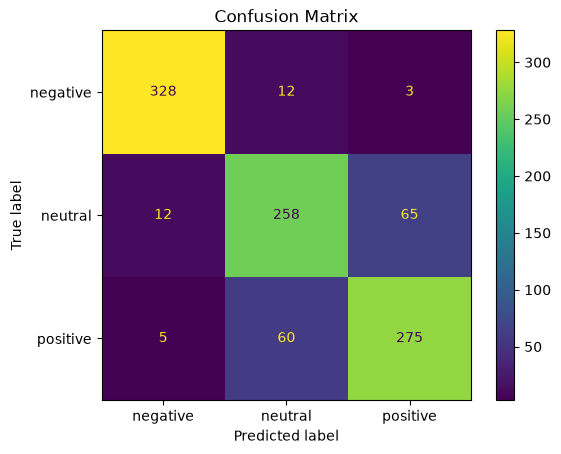

In [240]:
best_model = grid.best_estimator_
best_pred = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    best_pred,
    labels=best_model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.show()

## Task 20: Phân tích Confusion Matrix
1. Lớp nào bị nhầm nhiều nhất?
2. Nhầm `neutral → positive` có khác bản chất với `negative → positive` không?
3. Tính precision/recall/F1 riêng từng lớp.
4. Đề xuất cách giảm lỗi của lớp yếu nhất.

# 21. Accuracy, Precision, Recall, F1

In [241]:
print(classification_report(y_test, best_pred, zero_division=0))

p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
    y_test, best_pred, average="macro", zero_division=0
)
p_micro, r_micro, f_micro, _ = precision_recall_fscore_support(
    y_test, best_pred, average="micro", zero_division=0
)
p_weight, r_weight, f_weight, _ = precision_recall_fscore_support(
    y_test, best_pred, average="weighted", zero_division=0
)

print("Macro F1   :", round(f_macro, 4))
print("Micro F1   :", round(f_micro, 4))
print("Weighted F1:", round(f_weight, 4))

              precision    recall  f1-score   support

    negative       0.95      0.96      0.95       343
     neutral       0.78      0.77      0.78       335
    positive       0.80      0.81      0.81       340

    accuracy                           0.85      1018
   macro avg       0.84      0.85      0.84      1018
weighted avg       0.85      0.85      0.85      1018

Macro F1   : 0.8449
Micro F1   : 0.8458
Weighted F1: 0.8456


## Task 21: Macro / Micro / Weighted
1. Tạo một dataset mất cân bằng.
2. Chứng minh Accuracy vẫn cao dù lớp thiểu số dự đoán kém.
3. So sánh:
   - macro F1,
   - micro F1,
   - weighted F1.
4. Trong bài toán giáo dục, khi nào macro F1 quan trọng hơn accuracy?

# 22. ROC-AUC cho bài toán nhị phân

Ta chuyển sentiment thành:
- positive
- non-positive

Logistic Regression có `predict_proba`, phù hợp để minh họa ROC.

ROC-AUC: 1.0


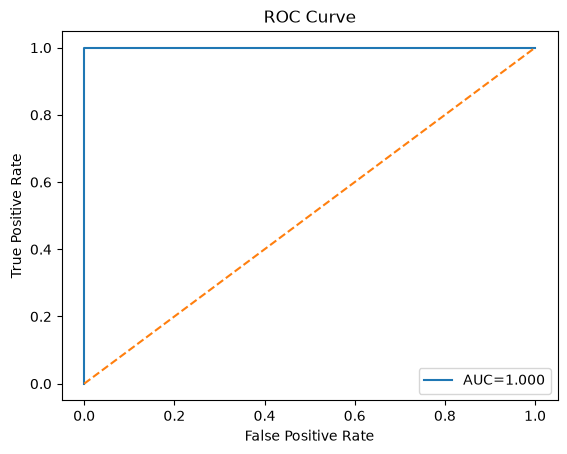

In [242]:
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    df["text_norm"],
    df["binary_sentiment"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["binary_sentiment"]
)

binary_lr = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", LogisticRegression(max_iter=2000))
])
binary_lr.fit(Xb_train, yb_train)

classes = list(binary_lr.named_steps["clf"].classes_)
pos_idx = classes.index("positive")
proba = binary_lr.predict_proba(Xb_test)[:, pos_idx]
y_true_binary = (yb_test == "positive").astype(int)

auc = roc_auc_score(y_true_binary, proba)
fpr, tpr, thresholds = roc_curve(y_true_binary, proba)

print("ROC-AUC:", round(auc, 4))

plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Task 22: Threshold tuning
1. Không dùng mặc định threshold 0.5.
2. Thử threshold:
   - 0.3,
   - 0.4,
   - 0.5,
   - 0.6,
   - 0.7.
3. Vẽ Precision/Recall theo threshold.
4. Chọn threshold phù hợp nếu:
   - false negative đắt hơn,
   - false positive đắt hơn.

In [243]:
# TODO: viết hàm evaluate_threshold(...)

# 23. Xử lý mất cân bằng

Các hướng:
- `class_weight`
- over-sampling
- under-sampling
- threshold tuning

Không được chỉ nhìn Accuracy.

In [244]:
# Tạo dữ liệu mất cân bằng minh họa
imbalanced = pd.concat([
    df[df.sentiment == "positive"],
    df[df.sentiment == "negative"].sample(10, random_state=RANDOM_STATE),
    df[df.sentiment == "neutral"].sample(8, random_state=RANDOM_STATE),
]).sample(frac=1, random_state=RANDOM_STATE)

print(imbalanced["sentiment"].value_counts())

sentiment
positive    40
negative    10
neutral      8
Name: count, dtype: int64


## Task 23: Imbalance
1. Train Logistic Regression:
   - không class weight,
   - `class_weight='balanced'`.
2. Tự viết random over-sampling.
3. Tự viết random under-sampling.
4. So sánh macro F1 và recall của lớp thiểu số.
5. Giải thích nguy cơ overfit khi oversampling dataset nhỏ.

In [245]:
def random_oversample(df_in, label_col, random_state=42):
    # TODO: sinh viên cài đặt
    pass

def random_undersample(df_in, label_col, random_state=42):
    # TODO: sinh viên cài đặt
    pass

# 24. Error Analysis theo chiều dài văn bản

In [246]:
error_df = pd.DataFrame({
    "text": X_test.values,
    "gold": y_test.values,
    "pred": best_pred
})

error_df["n_words"] = error_df["text"].str.split().map(len)
error_df["correct"] = error_df["gold"] == error_df["pred"]

def length_bucket(n):
    if n <= 7:
        return "short"
    elif n <= 12:
        return "medium"
    else:
        return "long"

error_df["length_group"] = error_df["n_words"].map(length_bucket)

display(error_df.head())
print(error_df.groupby("length_group")["correct"].mean())

,text,gold,pred,n_words,correct,length_group
0,"Môi trường học tập ô nhiễm, không có không khí...",negative,negative,12,True,medium
1,"Quạt điều hòa khá ồn, gây khó chịu khi học tập.",negative,negative,11,True,medium
2,Bạn của tôi rất sáng suốt và có óc quan sát tốt.,positive,positive,12,True,medium
3,Tôi học được nhiều điều thú vị và tinh hoa tro...,positive,positive,14,True,long
4,Cô ấy hay làm việc sai sót và không bao giờ tự...,negative,negative,17,True,long


length_group
long      0.833559
medium    0.871901
short     0.918919
Name: correct, dtype: float64


## Task 24: Error analysis bắt buộc
Phân tích ít nhất **20 dự đoán sai** và gán nguyên nhân:

- negation,
- sarcasm,
- emoji,
- teencode,
- code-switching,
- domain-specific,
- ambiguous,
- too short,
- rare vocabulary,
- preprocessing issue,
- annotation issue.

Mỗi lỗi phải có:
- text,
- gold,
- prediction,
- nhóm nguyên nhân,
- giải thích,
- đề xuất cải tiến.

In [247]:
mistakes = error_df[~error_df["correct"]].copy()
display(mistakes.head(20))

# TODO: thêm cột "error_category", "analysis", "proposed_fix"

,text,gold,pred,n_words,correct,length_group
10,Khu vực sống động của trường rất thú vị cho si...,neutral,positive,12,False,medium
14,Thầy đã giúp tôi có được nhiều kiến thức quan ...,neutral,positive,19,False,long
20,Cậu ấy có tầm nhìn xa và luôn đưa ra các chiến...,positive,neutral,26,False,long
21,Tôi cảm thấy giảng viên của mình không thực sự...,neutral,negative,20,False,long
22,Các buổi học được tổ chức chặt chẽ và có sự ch...,positive,neutral,15,False,long
23,"Giảng viên rất dễ tiếp cận và thân thiện, dễ t...",neutral,positive,18,False,long
32,"Cơ sở vật chất của trường khá đầy đủ, tuy nhiê...",neutral,negative,15,False,long
50,Cách đánh giá và phương pháp giảng dạy của trư...,positive,neutral,20,False,long
54,Thầy luôn đưa ra các gợi ý để sinh viên có thể...,neutral,positive,20,False,long
59,Một số bạn khá giỏi nhưng lúc làm việc chậm nh...,negative,neutral,12,False,medium


# 25. Bảng benchmark các baseline

In [248]:
models = {
    "Rule-based": None,
    "TFIDF + NB": nb_pipeline,
    "TFIDF + Logistic": lr_pipeline,
    "TFIDF + LinearSVM": svm_pipeline,
    "Decision Tree": tree_pipeline,
    "Random Forest": rf_pipeline,
}

records = []

# rule based
pred = rule_pred
p, r, f, _ = precision_recall_fscore_support(
    y_test, pred, average="macro", zero_division=0
)
records.append({
    "model": "Rule-based",
    "accuracy": accuracy_score(y_test, pred),
    "macro_f1": f,
    "train_seconds": 0.0,
    "interpretability": "high"
})

for name, model in models.items():
    if model is None:
        continue
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0
    pred = model.predict(X_test)

    p, r, f, _ = precision_recall_fscore_support(
        y_test, pred, average="macro", zero_division=0
    )
    records.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f,
        "train_seconds": elapsed,
        "interpretability": (
            "medium-high" if "Logistic" in name or "NB" in name
            else "medium"
        )
    })

benchmark_df = pd.DataFrame(records).sort_values("macro_f1", ascending=False)
display(benchmark_df)

,model,accuracy,macro_f1,train_seconds,interpretability
3,TFIDF + LinearSVM,0.846758,0.845548,0.962101,medium
2,TFIDF + Logistic,0.840864,0.839867,1.984903,medium-high
5,Random Forest,0.822200,0.820404,12.282669,medium
1,TFIDF + NB,0.792731,0.785213,0.377515,medium-high
4,Decision Tree,0.722004,0.725271,0.420402,medium
0,Rule-based,0.576621,0.574196,0.000000,high


## Task 25: Benchmark cải tiến
Bổ sung vào bảng:
- word unigram,
- word bigram,
- char n-gram,
- class weight,
- best tuned model,
- PhoBERT/ViSoBERT nếu chạy được.

Thêm:
- inference time / 1.000 câu,
- số feature / số parameter,
- kích thước model,
- mức độ giải thích.

# 26. PhoBERT / ViSoBERT — scaffold mở rộng

Phần này cần:
- Internet hoặc model đã tải sẵn,
- `transformers`,
- `datasets`,
- PyTorch,
- GPU nếu muốn fine-tune nhanh.

Mục tiêu:
- dùng cùng train/test split,
- fine-tune pretrained model,
- báo cáo cùng metric với baseline.

In [249]:
RUN_TRANSFORMER = False

if RUN_TRANSFORMER:
    # Ví dụ scaffold — sinh viên hoàn thiện
    #
    # from transformers import (
    #     AutoTokenizer,
    #     AutoModelForSequenceClassification,
    #     TrainingArguments,
    #     Trainer
    # )
    #
    # MODEL_NAME = "vinai/phobert-base"
    # tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    #
    # model = AutoModelForSequenceClassification.from_pretrained(
    #     MODEL_NAME,
    #     num_labels=3
    # )
    #
    # TODO:
    # 1. encode dataset
    # 2. map label -> id
    # 3. build Trainer
    # 4. fine-tune
    # 5. evaluate trên đúng test split
    #
    print("Transformer section enabled.")
else:
    print("Transformer section skipped. Set RUN_TRANSFORMER=True after installing dependencies.")

Transformer section skipped. Set RUN_TRANSFORMER=True after installing dependencies.


## Task 26: Pretrained model
Sinh viên chọn ít nhất một:
- PhoBERT
- ViSoBERT
- mô hình tiếng Việt tương đương được giảng viên chấp thuận.

Yêu cầu:
1. Fine-tune trên cùng split.
2. Báo cáo:
   - Accuracy,
   - Macro F1,
   - confusion matrix,
   - train time,
   - inference time.
3. Phân tích ít nhất 10 câu:
   - pretrained đúng nhưng baseline sai,
   - baseline đúng nhưng pretrained sai.
4. So sánh khả năng giải thích.

# 27. Bài so sánh

Sinh viên phải so sánh ít nhất:

### Hệ thống A
**TF-IDF + Naive Bayes**

### Hệ thống B
**TF-IDF + Logistic Regression hoặc Linear SVM**

### Hệ thống C
**PhoBERT hoặc ViSoBERT**

Dataset gợi ý:
- UIT-VSFC
- UIT-VSMEC
- sentiment / hate speech dataset tương đương

# 28. Yêu cầu cải tiến hệ thống

Ngoài ba hệ thống bắt buộc, nhóm phải thực hiện ít nhất **3 cải tiến** trong danh sách:

- [ ] word bigram / trigram
- [ ] character n-gram
- [ ] feature thủ công
- [ ] xử lý negation
- [ ] xử lý emoji
- [ ] xử lý teencode
- [ ] class weight
- [ ] oversampling
- [ ] threshold tuning
- [ ] hyperparameter tuning
- [ ] domain adaptation experiment
- [ ] ensemble
- [ ] custom preprocessing cho tiếng Việt

Mỗi cải tiến phải có:
1. giả thuyết/lý thuyết/phát biểu bài toán
2. thay đổi cụ thể,
3. metric trước,
4. metric sau,
5. giải thích kết quả.

# 29. Bài nộp

Notebook nộp phải có:

- [ ] Mô tả bài toán và label.
- [ ] Thống kê dataset.
- [ ] Train/validation/test split rõ ràng.
- [ ] TF-IDF + Naive Bayes.
- [ ] TF-IDF + Logistic Regression hoặc SVM.
- [ ] PhoBERT / ViSoBERT hoặc pretrained model tương đương.
- [ ] Confusion Matrix.
- [ ] Accuracy, Precision, Recall, F1.
- [ ] Macro / Micro / Weighted.
- [ ] Xử lý hoặc phân tích class imbalance.
- [ ] Ít nhất 20 failure cases được phân nhóm.
- [ ] So sánh training time.
- [ ] So sánh inference time.
- [ ] So sánh khả năng giải thích.
- [ ] Ít nhất 3 cải tiến so với baseline.

# 30. Bảng kết quả đề xuất

| Hệ thống | Representation | Accuracy | Macro F1 | Train time | Inference | Explainability |
|---|---|---:|---:|---:|---:|---|
| Rule-based | Lexicon | | | | | Cao |
| NB | TF-IDF | | | | | Cao |
| Logistic | TF-IDF | | | | | Khá cao |
| Linear SVM | TF-IDF | | | | | Khá |
| Improved Traditional | ... | | | | | ... |
| PhoBERT / ViSoBERT | Contextual Embedding | | | | | Thấp hơn |

### Câu hỏi bắt buộc
1. Mô hình nào tốt nhất theo Macro F1?
2. Mô hình nào nhanh nhất?
3. Mô hình nào dễ giải thích nhất?
4. Có đáng đổi tốc độ và khả năng giải thích để lấy thêm accuracy không?
5. Mô hình nào phù hợp nhất nếu triển khai CPU?

# 31. Rubric

| Thành phần | Điểm |
|---|---:|
| Dataset + split + chống leakage | 10 |
| Text representation | 15 |
| Naive Bayes baseline | 10 |
| Logistic/SVM baseline | 10 |
| Pretrained model | 15 |
| Evaluation đúng và đầy đủ | 15 |
| Ít nhất 3 cải tiến | 10 |
| Error analysis ≥ 20 cases | 10 |
| Trình bày + kết luận | 5 |
| **Tổng** | **100** |

### Điểm cộng
- Aspect-based sentiment
- Domain adaptation
- Robustness test với teencode / typo / emoji
- Calibration / threshold tuning
- Ensemble